# 物流销售综合分析

本 Notebook 使用 pandas 完成数据清洗与规整，使用 Matplotlib 进行可视化。原始数据位于 `E:/animal/data_wuliu.csv`，不会被覆盖。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from analysis import DEFAULT_SOURCE, load_and_clean, make_kpis, save_figures

OUTPUT_DIR = Path.cwd()
FIGURE_DIR = OUTPUT_DIR / 'figures'
pd.set_option('display.max_columns', 30)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. 读取与数据质量概览

In [2]:
raw = pd.read_csv(DEFAULT_SOURCE, encoding='gb18030', dtype='string')
print(f'原始数据形状：{raw.shape}')
display(raw.head())
display(pd.DataFrame({'缺失数量': raw.isna().sum(), '缺失率': raw.isna().mean()}))
print(f'完全重复记录数：{raw.duplicated().sum()}')

原始数据形状：(1161, 10)


,订单号,订单行,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额
0,P096311,10,2016-7-30,2016-9-30,晚交货,货品3,质量合格,华北,2,"1052,75元"
1,P096826,10,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10,"11,50万元"
2,<NA>,20,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10,"11,50万元"
3,P097435,10,2016-7-30,2016-9-30,按时交货,货品1,返修,华南,2,"6858,77元"
4,P097446,60,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15,"129,58元"


,缺失数量,缺失率
订单号,2,0.001723
订单行,0,0.000000
销售时间,0,0.000000
交货时间,0,0.000000
货品交货状况,2,0.001723
货品,0,0.000000
货品用户反馈,0,0.000000
销售区域,0,0.000000
数量,4,0.003445
销售金额,0,0.000000


完全重复记录数：9


## 2. 清洗与字段规整

In [3]:
df, quality = load_and_clean(DEFAULT_SOURCE)
print(f"清洗后数据形状：{df.shape}")
display(df.head())
display(df.dtypes.to_frame('数据类型'))
display(pd.DataFrame({'缺失数量': df.isna().sum()}))
display(df['data_quality_flag'].value_counts().to_frame('记录数'))

清洗后数据形状：(1152, 13)


,order_id,order_line,sale_date,delivery_date,delivery_status,product,customer_feedback,sales_region,quantity,sales_amount_cny,delivery_days,is_on_time,data_quality_flag
0,P096311,10,2016-07-30,2016-09-30,晚交货,货品3,质量合格,华北,2.0,1052.75,62,False,正常金额统计离群
1,P096826,10,2016-08-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,115000.0,61,True,正常数量统计离群;金额统计离群
2,<NA>,20,2016-08-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,115000.0,61,True,正常订单号缺失;数量统计离群;金额统计离群
3,P097435,10,2016-07-30,2016-09-30,按时交货,货品1,返修,华南,2.0,6858.77,62,True,正常金额统计离群
4,P097446,60,2016-11-26,2017-01-26,晚交货,货品3,质量合格,华北,15.0,129.58,61,False,正常数量统计离群


,数据类型
order_id,string
order_line,Int64
sale_date,datetime64[us]
delivery_date,datetime64[us]
delivery_status,string
product,string
customer_feedback,string
sales_region,string
quantity,Float64
sales_amount_cny,Float64


,缺失数量
order_id,2
order_line,0
sale_date,0
delivery_date,0
delivery_status,0
product,0
customer_feedback,0
sales_region,0
quantity,2
sales_amount_cny,0


,记录数
data_quality_flag,
正常,796
正常数量统计离群,194
正常金额统计离群,126
正常数量统计离群;金额统计离群,31
正常数量缺失或无效,2
正常订单号缺失;数量统计离群;金额统计离群,1
正常订单号缺失,1
正常金额非正,1


## 3. 核心指标

In [4]:
kpis = make_kpis(df)
display(kpis.to_frame('指标值'))
print(f"删除重复记录：{quality['duplicate_rows_removed']} 条")
print(f"按时交货率（未知状态不计入）：{kpis['按时交货率']:.2%}")

,指标值
清洗后记录数,1.152000e+03
订单数,8.680000e+02
销售数量合计,8.719250e+04
销售金额合计（元）,1.518926e+06
平均交货天数,7.563802e+01
按时交货率,8.852174e-01


删除重复记录：9 条
按时交货率（未知状态不计入）：88.52%


## 4. 月度趋势

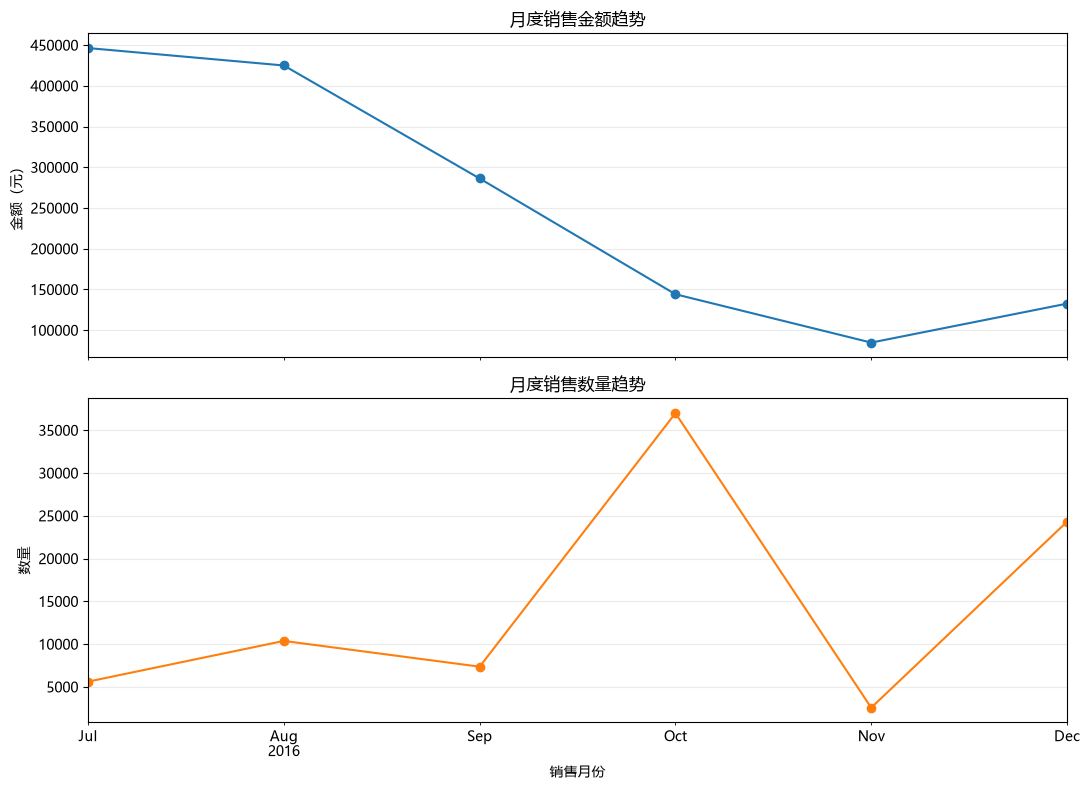

In [5]:
monthly = df.assign(month=df['sale_date'].dt.to_period('M')).groupby('month', observed=True).agg(
    sales_amount_cny=('sales_amount_cny', 'sum'), quantity=('quantity', 'sum')
)
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
monthly['sales_amount_cny'].plot(ax=axes[0], marker='o', color='#1f77b4', title='月度销售金额趋势')
monthly['quantity'].plot(ax=axes[1], marker='o', color='#ff7f0e', title='月度销售数量趋势')
axes[0].set_ylabel('金额（元）'); axes[1].set_ylabel('数量'); axes[1].set_xlabel('销售月份')
for ax in axes: ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 5. 区域与货品分析

In [6]:
region_summary = df.groupby('sales_region', dropna=False, observed=True).agg(
    销售金额=('sales_amount_cny', 'sum'), 销售数量=('quantity', 'sum'),
    平均交货天数=('delivery_days', 'mean'), 按时交货率=('is_on_time', 'mean')
).sort_values('销售金额', ascending=False)
product_summary = df.groupby('product', dropna=False, observed=True).agg(
    销售金额=('sales_amount_cny', 'sum'), 销售数量=('quantity', 'sum')
).sort_values('销售金额', ascending=False)
display(region_summary); display(product_summary)

,销售金额,销售数量,平均交货天数,按时交货率
sales_region,,,,
华北,750723.81,11914.5,76.980469,0.894531
华东,293196.29,53812.0,78.811688,0.87013
华南,245527.74,579.0,69.272727,0.909091
西北,127066.15,5240.0,70.491803,0.278689
马来西亚,71697.62,9913.0,74.295732,0.95107
泰国,30714.0,5734.0,72.994681,0.97861


,销售金额,销售数量
product,,
货品3,636947.38,9087.5
货品1,462150.58,3417.0
货品2,305366.79,55322.0
货品6,59527.12,8403.0
货品5,30714.0,5734.0
货品4,24219.74,5229.0


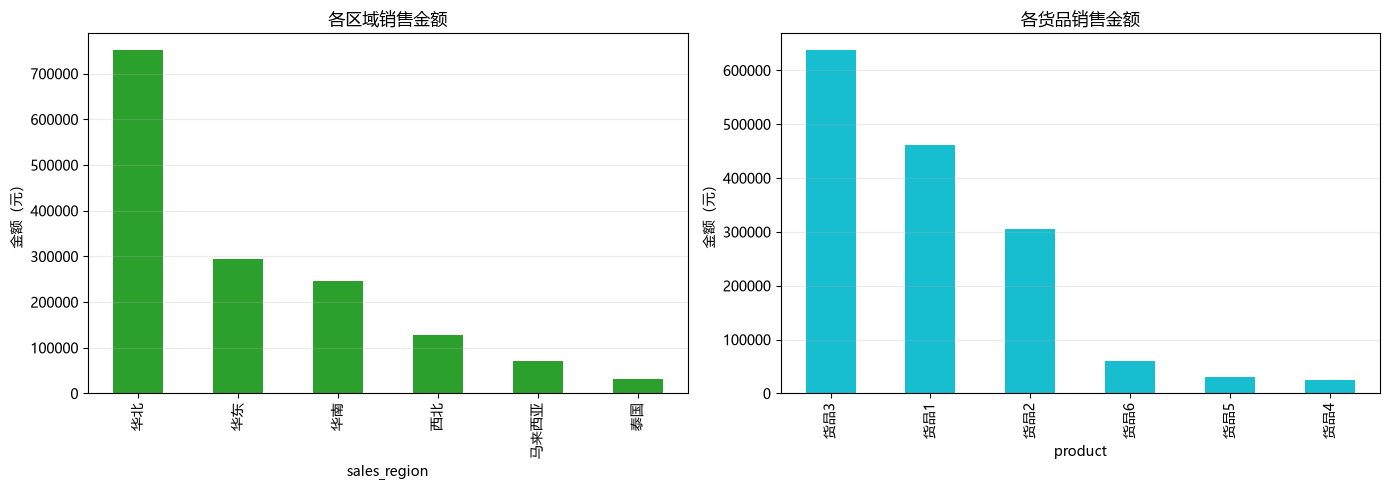

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_summary['销售金额'].plot(kind='bar', ax=axes[0], color='#2ca02c', title='各区域销售金额')
product_summary['销售金额'].plot(kind='bar', ax=axes[1], color='#17becf', title='各货品销售金额')
for ax in axes: ax.set_ylabel('金额（元）'); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## 6. 交付与用户反馈

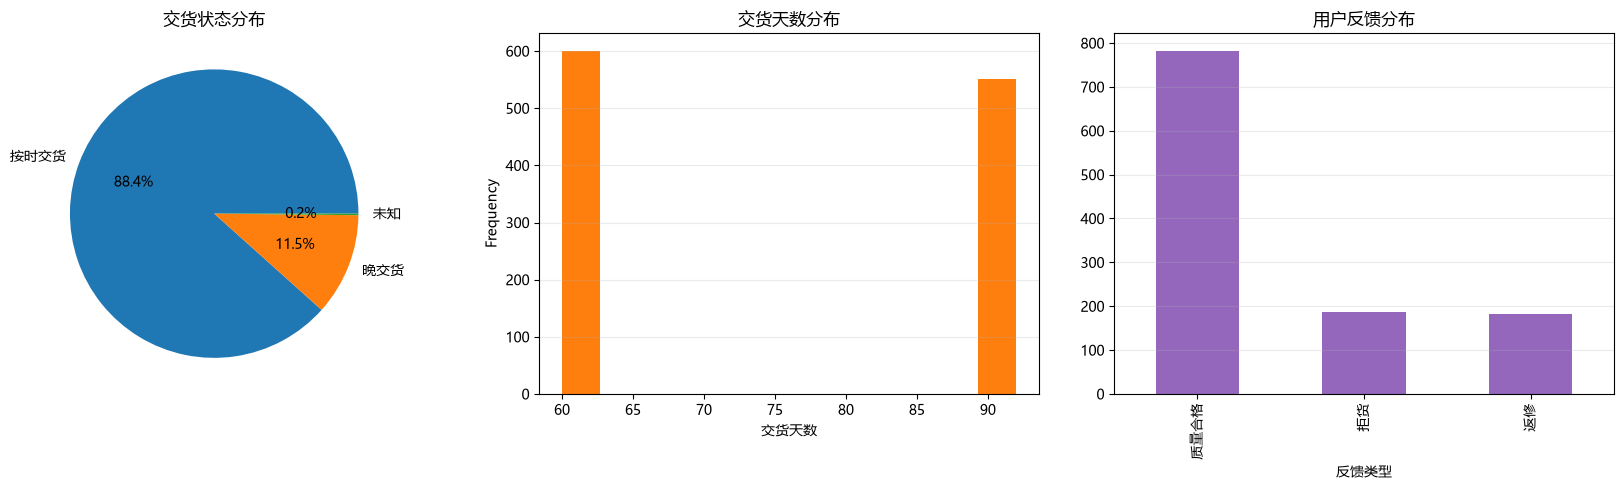

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
df['delivery_status'].value_counts().plot(kind='pie', autopct='%.1f%%', ax=axes[0], title='交货状态分布')
axes[0].set_ylabel('')
df['delivery_days'].dropna().plot(kind='hist', bins=12, ax=axes[1], color='#ff7f0e', title='交货天数分布')
df['customer_feedback'].value_counts().plot(kind='bar', ax=axes[2], color='#9467bd', title='用户反馈分布')
axes[1].set_xlabel('交货天数'); axes[2].set_xlabel('反馈类型')
for ax in axes[1:]: ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## 7. 输出结果

In [9]:
df.to_csv(OUTPUT_DIR / 'data_wuliu_cleaned.csv', index=False, encoding='utf-8-sig')
kpis.rename('value').to_csv(OUTPUT_DIR / 'kpis.csv', encoding='utf-8-sig')
pd.DataFrame({'metric': list(quality['clean_missing']), 'missing_count': list(quality['clean_missing'].values())}).to_csv(OUTPUT_DIR / 'quality_report.csv', index=False, encoding='utf-8-sig')
saved = save_figures(df, FIGURE_DIR)
print('已输出清洗数据、指标、质量报告和图表：')
for path in saved: print(path)

已输出清洗数据、指标、质量报告和图表：
E:\文档\python_learn\python-2\figures\01_月度销售金额趋势.png
E:\文档\python_learn\python-2\figures\02_区域销售金额.png
E:\文档\python_learn\python-2\figures\03_交货状态分布.png
E:\文档\python_learn\python-2\figures\04_交货天数分布.png
E:\文档\python_learn\python-2\figures\05_用户反馈分布.png
